# FS→DSA Finland — Exact Baseline Workflow

Purpose: Guarantee that all scenarios start from the same NFPC baseline and that a scenario with zero SPB change reproduces the NFPC DSA exactly, while any SPB change triggers endogenous responses.

Outline:
- Step 1: Exact NFPC replication from Table 17 (levels and growth) — produces `baseline_model`.
- Step 1b: Freeze NFPC baseline counterpart arrays into a reusable `scenario_template` for all subsequent runs.
- Step 2a: Apply MTP SPB path with NFPC anchors (only SPB differs) — endogenous DSA.
- Step 2b: Find binding SPB path (optimal) using the same NFPC anchors.
- Step 2c: Compare results in one chart.
- Step 3: Potential uplift with identical inflation to NFPC and recompute binding SPB.



In [1]:
import sys, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')

# Resolve project root
cwd = Path.cwd()
project_root = cwd if (cwd / '03_Modell').exists() else cwd.parent
sys.path.extend([
    str((project_root / '03_Modell').parent),
    str(project_root / '03_Modell' / 'EU_DSA' / 'code' / 'classes')
])

from EU_DSA.code.classes import StochasticDsaModel as DSA
from FS_Model.integration import apply_mtp_anchors_to_dsa
from EU_DSA.code.functions import scenario_workflow  # New workflow functions
from FS_Model.data_functions import load_and_process_data
from FS_Model.model_equations import build_model
from FS_Model.scenario_functions import initialize_model, run_scenario_analysis
from FS_Model.integration import apply_mtp_anchors_to_dsa, apply_fs_potential_to_dsa, run_dsa_with_potential_and_spb


START_YEAR, END_YEAR = 2024, 2041
ADJUSTMENT_START_YEAR = 2025
ADJUSTMENT_PERIOD = 7

print('Project root:', project_root)


Project root: c:\Users\dzsve\OneDrive - Dezernat Zukunft e.V\DZ-Schalte - Dokumente\2_Projekte\Fiskalpolitik\F48_EUCAM_DSA_Reformvorschlag


In [2]:
# load data and initialise FS model
FI = load_and_process_data(data_folder='02_Daten', sheet_name='Finland')
FS_model = build_model(include_fiscal=True,include_kg_lag=False)
data_FI = FS_model.insertModelVar(FI)
print('FI data shape:', FI.shape)

FI data shape: (84, 223)


In [3]:
# Initialize template DSA model
dsa_template = DSA(
    country='FIN',
    start_year=START_YEAR,
    end_year=END_YEAR,
    adjustment_period=ADJUSTMENT_PERIOD,
    adjustment_start_year=ADJUSTMENT_START_YEAR,
    fiscal_multiplier_type='ec'
)
dsa_template.project()
df_template = dsa_template.df(all=True)


a0 = dsa_template.adjustment_start
#a1 = dsa_template.adjustment_end
#closure_end = a1 + dsa_template.fiscal_multiplier_persistence
years = list(range(START_YEAR, END_YEAR + 1))

In [4]:
# NFPC inputs (Table 17) and MTP SPB
rg_pot_nfpc = pd.Series({
    2024: 0.93, 2025: 0.93, 2026: 0.93, 2027: 0.93, 2028: 0.93, 2029: 0.93, 2030: 0.93, 2031: 0.93,
    2032: 0.93, 2033: 0.93, 2034: 0.93, 2035: 0.93, 2036: 0.93, 2037: 0.93, 2038: 0.93, 2039: 0.93, 2040: 0.93, 2041: 0.93
}).reindex(years)

rg_nfpc = pd.Series({
    2024: -0.2, 2025: 1.8, 2026: 1.8, 2027: 1.8, 2028: 1.8, 2029: 0.9, 2030: 0.9, 2031: 0.9,
    2032: 0.9, 2033: 0.9, 2034: 0.9, 2035: 0.9, 2036: 0.9, 2037: 0.9, 2038: 0.9, 2039: 0.9, 2040: 0.9, 2041: 0.9
}).reindex(years)

pi_nfpc = pd.Series({
    2024: 1.7, 2025: 2.1, 2026: 2.2, 2027: 2.2, 2028: 2.3, 2029: 2.3, 2030: 2.4, 2031: 2.4,
    2032: 2.5, 2033: 2.6, 2034: 2.5, 2035: 2.5, 2036: 2.5, 2037: 2.4, 2038: 2.4, 2039: 2.4, 2040: 2.4, 2041: 2.3
}).reindex(years)

spb_target = pd.Series({
    2024: -0.37,     2025: 0.44,     2026: 1.1,     2027: 1.42,     2028: 1.78,     2029: 2.06,     2030: 2.34,     2031: 2.62, 
    2032: 2.62,     2033: 2.62,     2034: 2.62,     2035: 2.62,     2036: 2.62,     2037: 2.62,     2038: 2.62,     2039: 2.62,     2040: 2.62,     2041: 2.62, 
}).reindex(years)

## Step 1 — NFPC replication (Table 17)


In [46]:
# STEP 1: Create NFPC Baseline using new workflow function
print("Step 1: Creating NFPC baseline...")
NFPC = scenario_workflow.create_nfpc_baseline(
    rg=rg_nfpc,
    rg_pot=rg_pot_nfpc,
    pi=pi_nfpc,
    dsa_model=dsa_template,
    spb_baseline=-0.4,
    inplace=False
)
df_NFPC = NFPC.df(all=True)

# Verify NFPC baseline
print("\n=== NFPC Baseline Created ===")
for t, year in enumerate(range(2025, 2032)):
    print(f"Output gap in year {year} (t={t+1}): {NFPC.output_gap_bl[t+1]:.4f}%")


Step 1: Creating NFPC baseline...

=== NFPC Baseline Created ===
Output gap in year 2025 (t=1): -2.0987%
Output gap in year 2026 (t=2): -1.2548%
Output gap in year 2027 (t=3): -0.8366%
Output gap in year 2028 (t=4): -0.4183%
Output gap in year 2029 (t=5): 0.0000%
Output gap in year 2030 (t=6): 0.0000%
Output gap in year 2031 (t=7): 0.0000%


## Step 2a — Apply MTP SPB (NFPC anchors; start from `scenario_template`)


In [47]:
## Step 2a — Apply MTP SPB (NFPC anchors) using new workflow function

# Calculate SPB steps from the MTP target path
spb_steps_mtp = np.zeros(ADJUSTMENT_PERIOD)
for tt in range(NFPC.adjustment_start, NFPC.adjustment_end + 1):
    yy = NFPC.start_year + tt
    spb_steps_mtp[tt - NFPC.adjustment_start] = spb_target.loc[yy] - spb_target.loc[yy - 1]

print(f"MTP SPB steps: {spb_steps_mtp}")

# Use new workflow function to create MTP scenario
print("\nCreating MTP scenario with predefined SPB steps...")
scenario_mtp, spb_steps_used, binding_spb = scenario_workflow.create_mtp_scenario(
    baseline_nfpc=NFPC,
    spb_steps_mtp=spb_steps_mtp,
    inplace=False
)

df_sce_mtp = scenario_mtp.df(all=True)
print('Step 2a: MTP SPB scenario created successfully.')


MTP SPB steps: [0.81 0.66 0.32 0.36 0.28 0.28 0.28]

Creating MTP scenario with predefined SPB steps...
Step 2a: MTP SPB scenario created successfully.


## Step 2b — Binding SPB path from NFPC anchors


In [48]:
## Step 2b — Binding SPB path from NFPC anchors using new workflow function

print("Finding binding SPB path...")
binding_mtp, spb_steps_binding, binding_spb_target = scenario_workflow.create_mtp_scenario(
    baseline_nfpc=NFPC,
    use_find_binding=True,  # Use find_spb_binding method
    edp=True,
    debt_safeguard=True,
    deficit_resilience=True,
    inplace=False
)

df_binding_mtp = binding_mtp.df(all=True)
print(f"Binding SPB target (2031): {binding_spb_target:.3f}%")
print(f"Binding SPB steps: {spb_steps_binding}")


Finding binding SPB path...
Upper bound too restrictive, adjusting to [-10, 9.5]
Upper bound too restrictive, adjusting to [-10, 9.0]
Upper bound too restrictive, adjusting to [-10, 8.5]
Upper bound too restrictive, adjusting to [-10, 8.0]
Upper bound too restrictive, adjusting to [-10, 7.5]
SPB optimization succeeded with bounds [-10, 7.5] (adjusted 5 times)
Binding SPB target (2031): 2.270%
Binding SPB steps: [0.5        0.36173859 0.36173859 0.36173859 0.36173859 0.36173859
 0.36173859]


## Step 2c — Comparison chart


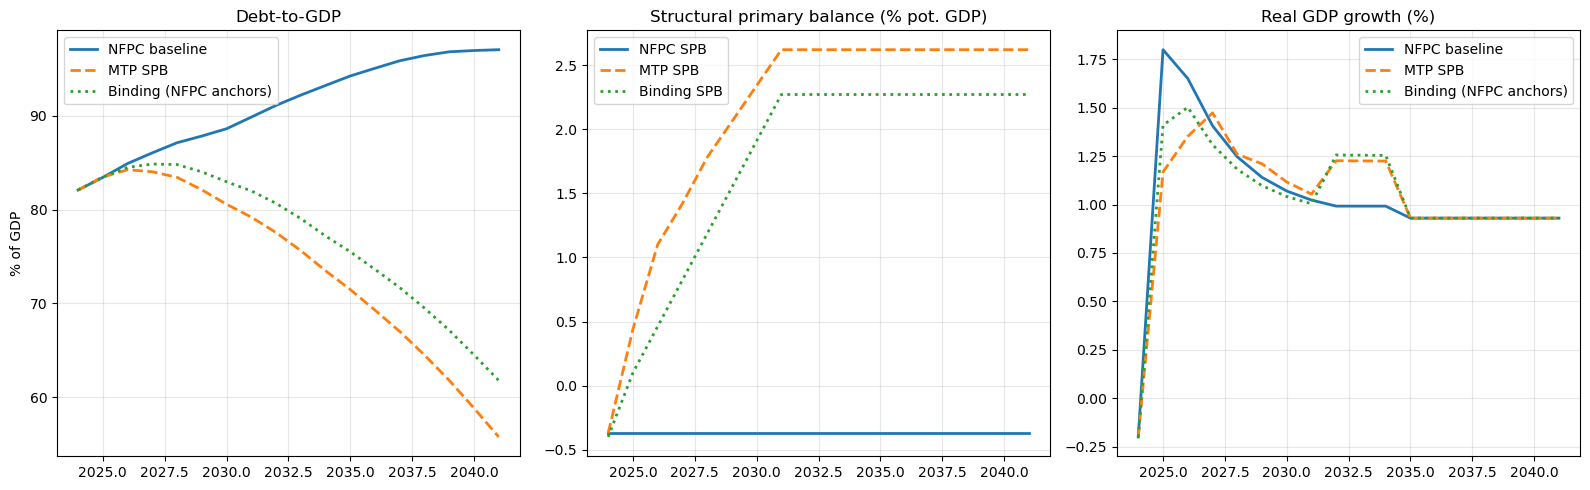

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Debt paths
ax = axes[0]
ax.plot(years, NFPC.d[:len(years)], label='NFPC baseline', lw=2)
ax.plot(years, scenario_mtp.d[:len(years)], '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.d[:len(years)], ':', label='Binding (NFPC anchors)', lw=2)
ax.set_title('Debt-to-GDP'); ax.set_ylabel('% of GDP'); ax.grid(True, alpha=0.3); ax.legend()

# SPB
ax = axes[1]
ax.plot(years, np.full(len(years), -0.37), label='NFPC SPB', lw=2)
ax.plot(years, spb_target.values, '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.spb_bca[:len(years)], ':', label='Binding SPB', lw=2)
ax.set_title('Structural primary balance (% pot. GDP)'); ax.grid(True, alpha=0.3); ax.legend()

# Real growth
ax = axes[2]
ax.plot(years, NFPC.rg[:len(years)], label='NFPC baseline', lw=2)
ax.plot(years, scenario_mtp.rg[:len(years)], '--', label='MTP SPB', lw=2)
ax.plot(years, binding_mtp.rg[:len(years)], ':', label='Binding (NFPC anchors)', lw=2)
ax.set_title('Real GDP growth (%)'); ax.grid(True, alpha=0.3); ax.legend()

plt.tight_layout(); plt.show()


## Step 3 — Potential uplift (optional) with same inflation (NFPC)


In [49]:
#interpret: absolute means the value is added to the baseline value in that year, delta means only the change to the previous year is added
measures_invest = [
    # Measure 4:
    # Public investment
    { 'var': 'S_IG_STAR', 'values': [0.07, 0.14, 0.21, 0.28, 0.35, 0.42], 'interpret': 'absolute', 'persist': False, 'persist_mode': 'copy_last' },
    # Private Investment
    { 'var': 'EPS_IQ_M', 'values': [0.08, 0.16, 0.24, 0.32, 0.4, 0.48], 'interpret': 'absolute', 'persist': False, 'persist_mode': 'copy_last' },
]

measures_tfp_invest = [
    # Measure 4:
    # Public investment
    { 'var': 'S_IG_STAR', 'values': [0.07, 0.14, 0.21, 0.28, 0.35, 0.42], 'interpret': 'absolute', 'persist': False, 'persist_mode': 'copy_last' },
    # Private Investment
    { 'var': 'EPS_IQ_M', 'values': [0.08, 0.16, 0.24, 0.32, 0.4, 0.48], 'interpret': 'absolute', 'persist': False, 'persist_mode': 'copy_last' },
    # TFP impact: 0.30% increase in SR_TREND (0.0075 absolute increase) starting in 2029
    { 'var': 'EPS_SR', 'values': [0, 0, 0, 0, 0, 0.000964, 0.000964, 0.000964, 0.000964, 0.000964, 0.000964], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'plateau' },
]

In [50]:
# Extract paths from the binding DSA model
rg = pd.Series(NFPC.rg, index=years, name='rg')
rg_pot = pd.Series(NFPC.rg_pot, index=years, name='rg_pot')
pi = pd.Series(NFPC.pi, index=years, name='pi')
   
# Create the anchors dictionary
bl_anchors = {
    'rg': rg,
    'rg_pot': rg_pot,
    'pi': pi
}

FS_bl_FI = initialize_model(
    data=data_FI, 
    model_class=FS_model, 
    start=ADJUSTMENT_START_YEAR, 
    end=END_YEAR,
    interest_method='exogenous', 
    baseline_method='DSA_MTP',  
    beta_d_assumption='zero', 
    dsa_model=copy.deepcopy(NFPC),  # Use the NFPC model
    mtp_anchors=bl_anchors,
)


Finding instruments :   0%|          | 0/17

In [51]:
#First PO impact from investment --> this should be incorporated into scenario DSA with fixed GDP

FS_sce_FI = run_scenario_analysis(
    baseline_result=FS_bl_FI, model_class=FS_model,
    scenario_shocks=measures_tfp_invest, scenario_name='FI_policy_invest', allow_fixed_shocks=True
)

,Period 1,Period 2,Period 3,Period 4,Period 5,Period 6,Period 7,Period 8,Period 9,Period 10,Period 11
S_IG_STAR,0.070,0.140,0.210,0.280,0.350,0.420,0.000,0.000,0.000,0.000,0.000
EPS_IQ_M,0.080,0.160,0.240,0.320,0.400,0.480,0.000,0.000,0.000,0.000,0.000
EPS_SR,0.000,0.000,0.000,0.000,0.000,0.001,0.001,0.001,0.001,0.001,0.001


Finding instruments :   0%|          | 0/3

Finding instruments :   0%|          | 0/7

In [52]:
# Calculate total growth from 2024 to 2041 for Finland (AT)
start_value = FS_bl_FI.loc[2024, 'Y_STAR']
end_value = FS_sce_FI.loc[2041, 'Y_STAR']
total_growth_factor = end_value / start_value

# Calculate the constant annual growth rate from 2025 to 2041 (17 years)
years_span = 2041 - 2024  # 17 years
constant_growth_rate = (total_growth_factor ** (1/years_span)) - 1

# Create smoothed Y_STAR series with constant growth
FS_sce_FI['Y_STAR_smooth'] = FS_sce_FI['Y_STAR'].copy()
FS_sce_FI.loc[2024, 'Y_STAR_smooth'] = start_value

# Apply constant growth from 2025 onwards
for year in range(2025, 2042):
    FS_sce_FI.loc[year, 'Y_STAR_smooth'] = start_value * ((1 + constant_growth_rate) ** (year - 2024))

# Calculate the smoothed growth rates
FS_sce_FI['Y_STAR_growth_smooth'] = FS_sce_FI['Y_STAR_smooth'].pct_change() * 100

print(f"Total growth factor: {total_growth_factor:.4f}")
print(f"Constant annual growth rate: {constant_growth_rate*100:.2f}%")
print(f"Growth from 2024 to 2041: {(total_growth_factor-1)*100:.2f}%")

Total growth factor: 1.1847
Constant annual growth rate: 1.00%
Growth from 2024 to 2041: 18.47%


In [53]:
# Create DSA model
binding_PREM = copy.deepcopy(NFPC)

# Apply only potential output from FS scenarios to DSA models
apply_fs_potential_to_dsa(
    binding_PREM, 
    fs_df=FS_sce_FI, 
    use_smoothed_growth=True,
    smooth_start_year=2024,  # Your start year
    smooth_end_year=2041     # Your end year
)

# Now run DSA projections
binding_PREM.find_spb_binding(
        print_results=True
    )
df_binding_PREM = binding_PREM.df(all=True)
    
sce_opt_tgt = float(binding_PREM.binding_spb_target)
sce_opt_steps = binding_PREM.binding_parameter_dict['spb_steps'].copy()

print(f"Baseline Binding: {binding_mtp.spb_bca[7]:.4f}% vs Scenario Binding: {binding_PREM.binding_spb_target:.4f}%")


Upper bound too restrictive, adjusting to [-10, 9.5]
Upper bound too restrictive, adjusting to [-10, 9.0]
Upper bound too restrictive, adjusting to [-10, 8.5]
Upper bound too restrictive, adjusting to [-10, 8.0]
Upper bound too restrictive, adjusting to [-10, 7.5]
SPB optimization succeeded with bounds [-10, 7.5] (adjusted 5 times)
                  Model Params                              SPB Targets       
================================================     =========================
country                                      FIN     main_adjustment     0.831
adjustment period                              7     lower_spb           1.047
adjustment start                            2025     financial_stress    0.989
shock frequency                        quarterly     adverse_r_g         1.340
stochastic period                      2032-2037     deficit_reduction  -0.351
estimation                                normal     stochastic          1.379
bond level data                   

## 4) Results

In [57]:
# SPB, Debt Ratio, and Potential Output Growth comparison - Baseline vs Scenario for Finland

years_fi = range(2024, 2042)  # 2024-2041 for Finland

# Helper function to get EUR values (Finland)
def get_eur_values_fi(model, year, var):
    if model.start_year <= year <= model.start_year + len(model.spb_bca) - 1:
        idx = year - model.start_year
        return getattr(model, var)[idx] * model.ngdp[idx] / 100 * 1e9
    return np.nan

# Helper function to get percentage values (Finland)
def get_pct_values_fi(model, year, var):
    if hasattr(model, var):
        arr = getattr(model, var)
        if model.start_year <= year <= model.start_year + len(arr) - 1:
            idx = year - model.start_year
            return arr[idx]
    return np.nan

# Create data dictionary for Finland, including debt ratio and potential output growth
results_fi = {
    'Year': list(years_fi),
    'SPB_Baseline_%': [get_pct_values_fi(binding_mtp, y, 'spb_bca') for y in years_fi],
    'SPB_Scenario_%': [get_pct_values_fi(binding_PREM, y, 'spb_bca') for y in years_fi],
    'SPB_Baseline_EUR': [get_eur_values_fi(binding_mtp, y, 'spb_bca') for y in years_fi],
    'SPB_Scenario_EUR': [get_eur_values_fi(binding_PREM, y, 'spb_bca') for y in years_fi],
    'Debt_Baseline_%': [get_pct_values_fi(binding_mtp, y, 'd') for y in years_fi],
    'Debt_Scenario_%': [get_pct_values_fi(binding_PREM, y, 'd') for y in years_fi],
    'PotOut_Growth_Baseline_%': [get_pct_values_fi(binding_mtp, y, 'rg_pot') for y in years_fi],
    'PotOut_Growth_Scenario_%': [get_pct_values_fi(binding_PREM, y, 'rg_pot') for y in years_fi],
}

# Create DataFrame for Finland
comparison_df_fi = pd.DataFrame(results_fi)

# Calculate differences for Finland
comparison_df_fi['SPB_Diff_%'] = comparison_df_fi['SPB_Scenario_%'] - comparison_df_fi['SPB_Baseline_%']
comparison_df_fi['SPB_Diff_EUR'] = comparison_df_fi['SPB_Scenario_EUR'] - comparison_df_fi['SPB_Baseline_EUR']
comparison_df_fi['Debt_Diff_%'] = comparison_df_fi['Debt_Scenario_%'] - comparison_df_fi['Debt_Baseline_%']
comparison_df_fi['PotOut_Growth_Diff_%'] = comparison_df_fi['PotOut_Growth_Scenario_%'] - comparison_df_fi['PotOut_Growth_Baseline_%']

print("SPB, Debt Ratio, and Potential Output Growth Comparison (Finland):")
# Format EUR columns to show in billions (no scientific notation)
eur_cols_fi = ['SPB_Baseline_EUR', 'SPB_Scenario_EUR', 'SPB_Diff_EUR']
comparison_df_display_fi = comparison_df_fi.copy()
for col in eur_cols_fi:
    comparison_df_display_fi[col] = comparison_df_display_fi[col].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")

display(comparison_df_display_fi.round(3))

SPB, Debt Ratio, and Potential Output Growth Comparison (Finland):


,Year,SPB_Baseline_%,SPB_Scenario_%,SPB_Baseline_EUR,SPB_Scenario_EUR,Debt_Baseline_%,Debt_Scenario_%,PotOut_Growth_Baseline_%,PotOut_Growth_Scenario_%,SPB_Diff_%,SPB_Diff_EUR,Debt_Diff_%,PotOut_Growth_Diff_%
0,2024,-0.400,-0.400,"-1,104,688,000","-1,104,688,000",82.087,82.087,0.930,1.002,0.000,0,0.000,0.072
1,2025,0.100,0.100,"285,947,599","286,150,862",83.457,83.399,0.930,1.002,0.000,"203,263",-0.057,0.072
2,2026,0.462,0.441,"1,369,653,221","1,311,407,491",84.496,84.380,0.930,1.002,-0.020,"-58,245,731",-0.116,0.072
3,2027,0.823,0.783,"2,529,108,075","2,409,969,200",84.852,84.696,0.930,1.002,-0.041,"-119,138,875",-0.156,0.072
4,2028,1.185,1.124,"3,767,840,918","3,585,271,279",84.797,84.620,0.930,1.002,-0.061,"-182,569,639",-0.177,0.072
5,2029,1.547,1.466,"5,086,151,818","4,837,700,260",84.025,83.847,0.930,1.002,-0.081,"-248,451,557",-0.177,0.072
6,2030,1.909,1.807,"6,493,038,391","6,175,945,825",82.962,82.805,0.930,1.002,-0.102,"-317,092,566",-0.157,0.072
7,2031,2.270,2.148,"7,988,406,383","7,600,071,095",81.996,81.880,0.930,1.002,-0.122,"-388,335,289",-0.116,0.072
8,2032,2.270,2.148,"8,290,957,641","7,892,406,339",80.667,80.615,0.930,1.002,-0.122,"-398,551,301",-0.052,0.072
9,2033,2.270,2.148,"8,613,273,481","8,203,904,535",79.046,79.066,0.930,1.002,-0.122,"-409,368,946",0.021,0.072


In [56]:
# Save the comparison dataframe for Finland
comparison_df_fi.to_excel('Finland_Results_v3.xlsx', index=False)
print("DataFrame saved as 'Finland_Results_v3.xlsx'")

DataFrame saved as 'Finland_Results_v3.xlsx'
